In [1]:
import random
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
class TimeScheme(object):
	def __init__(self, dt):
		self.dt = dt

	def EulerForward(self, u, rhs, i, j):
		return u[i][j] + self.dt * rhs(u[i], i, j)

	def EulerBackward(self, u, rhs, i, j):
		return u[i][j] + self.dt * rhs(u[i+1], i, j)

	def CrankNicolson(self, u, rhs, i, j):
		return u[i][j] + self.dt * rhs(0.5*(u[i]+u[i+1]), j)

	def RungeKutta(self, u, rhs, i, j):
		k1 = rhs(u[i], i, j)
		k2 = rhs(u[i] + 0.5*self.dt*k1, i, j)
		k3 = rhs(u[i] + 0.5*self.dt*k2, i, j)
		k4 = rhs(u[i] + self.dt*k3, i, j)
		return u[i][j] + self.dt*(k1 + 2*k2 + 2*k3 + k4)/6	
		


In [3]:
class SpatialScheme:
	def Central(self, u, i):
		return u[i+1] - u[i-1]
	def Central2(self, u, i):
		return u[i+1] - 2 * u[i] + u[i-1]
	def Central4(self, u, i):
		return 1/12 * u[i-2] - 2/3 * u[i-1] + 2/3 * u[i+1] - 1/12 * u[i+2]
	def Central5(self, u, i):
		return 1/12 * u[i-2] - 4/3 * u[i-1] + 5/2 * u[i] - 4/3 * u[i+1] + 1/12 * u[i+2]

	def Upwind(self, u, i):
		return u[i]
		
	def ENO1(self, u, i):
		return 11/6 * u[i] - 7/6 * u[i-1] + 1/3 * u[i-2]
	def ENO2(self, u, i):
		return -1/6 * u[i-1] + 5/6 * u[i] + 1/3 * u[i+1]
	def ENO3(self, u, i):
		return 1/3 * u[i] + 5/6 * u[i+1] - 1/6 * u[i+2]

	def ENO(self, u, i):
		return 1/10 * self.ENO1(u, i) + 3/5 * self.ENO2(u, i) + 3/10 * self.ENO3(u, i)
	
	def WENO(self, u, i):
		beta1 = 13/12 * (u[i-2] - 2*u[i-1] + u[i])**2 + 1/4 * (u[i-2] - 4*u[i-1] + 3*u[i])**2
		beta2 = 13/12 * (u[i-1] - 2*u[i] + u[i+1])**2 + 1/4 * (u[i-1] - u[i+1])**2
		beta3 = 13/12 * (u[i] - 2*u[i+1] + u[i+2])**2 + 1/4 * (-3*u[i] + 4*u[i+1] - u[i+2])**2
		
		epsilon = 1e-6
		alpha1 = 0.1 / (beta1 + epsilon)**2
		alpha2 = 0.6 / (beta2 + epsilon)**2
		alpha3 = 0.3 / (beta3 + epsilon)**2
		
		omega_sum = alpha1 + alpha2 + alpha3
		w1 = alpha1 / omega_sum
		w2 = alpha2 / omega_sum
		w3 = alpha3 / omega_sum
		return w1 * self.ENO1(u, i) + w2 * self.ENO2(u, i) + w3 * self.ENO3(u, i)
			


In [4]:


class BurgersPINN(nn.Module):
    """用于Burgers方程的Physics-Informed Neural Network"""
    def __init__(self, layers):
        super(BurgersPINN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers)-2:  # 最后一层不加激活函数
                self.layers.append(nn.Tanh())
                
    def forward(self, x):
        """前向传播：输入[x, t]，输出u(x,t)"""
        for layer in self.layers:
            x = layer(x)
        return x
    
    def burgers_residual(self, x, t, vic):
        """
        计算Burgers方程的残差
        Burgers方程: ∂u/∂t + u·∂u/∂x = ν·∂²u/∂x²
        """
        x.requires_grad_(True)
        t.requires_grad_(True)
        u = self(torch.cat([x, t], dim=1))
        
        # 计算一阶导数 ∂u/∂t 和 ∂u/∂x
        u_t = torch.autograd.grad(u.sum(), t, create_graph=True)[0]
        u_x = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
        
        # 计算二阶导数 ∂²u/∂x²
        u_xx = torch.autograd.grad(u_x.sum(), x, create_graph=True)[0]
        
        # 计算Burgers方程残差
        f = u_t + u * u_x - vic * u_xx
        return f

class FiniteDifference:
    def __init__(self, timescheme, spacescheme, nt, nx, endntime, endnspace, vic):
        self.timescheme = timescheme
        self.spacescheme = spacescheme
        self.endntime = endntime
        self.endnspace = endnspace
        self.ntime = nt
        self.nspace = nx
        self.dt = endntime / nt
        self.dx = endnspace / nx
        print(f"CFL Number : {self.dt/self.dx}")
        self.vic = vic

        self.field = np.zeros((self.ntime, 3 * self.nspace))
        self.field[0] = self.initial_conditions()
        self.boundary_conditions(1)
        self.D2 = self.compute_D2_matrix(nx, endnspace)        

    def compute_D2_matrix(self, nx, endnspace):
        """计算二阶导数离散矩阵 (周期边界)"""
        dx = endnspace / nx
        D2 = np.zeros((nx, nx))
        for i in range(nx):
            D2[i, (i-1) % nx] = 1 / dx**2
            D2[i, i] = -2 / dx**2
            D2[i, (i+1) % nx] = 1 / dx**2
        return D2

    def initial_conditions(self):
        a = np.sin(np.linspace(0, self.endnspace, self.nspace)) + 10
        return np.concatenate((a, a, a))

    def boundary_conditions(self, i):
        self.field[i, 0: self.nspace] = self.field[i-1, self.nspace: 2 * self.nspace]
        self.field[i, 2*self.nspace:] = self.field[i-1, self.nspace: 2 * self.nspace]

    def res(self, u, i):
        return (-u[i + 2] + 16 * u[i + 1] - 30 * u[i] + 16 * u[i - 1] - u[i - 2]) / (12 * self.dx**2)

    def flux(self, u, i):
        ul, ur = self.spacescheme(u, i), self.spacescheme(u, i+1)
        fl, fr = 0.5 * ul**2, 0.5 * ur**2
        a = np.abs((fl-fr)/(ul-ur + 1e-8))
        return 0.5 * (fl + a * ul) + 0.5 * (fr - a * ur)

    def rhs(self, u, i, j):
        return -(self.flux(u, j) - self.flux(u, j-1)) / self.dx + self.vic * self.res(u, j)

    def solve(self):
        for i in range(1, self.ntime):
            self.boundary_conditions(i)
            for j in range(self.nspace, 2 * self.nspace):
                self.field[i][j] = self.timescheme(self.field, self.rhs, i-1, j)
            if (i % 500 == 0 or i == self.ntime-1):
                self.plot(i)
                self.post_process(i)
                plt.show()

    def plot(self, i):
        plt.plot(self.field[i, self.nspace: 2*self.nspace], label=f'Time step: {i}')
        plt.grid(True)
        plt.title(f'Time step: {i}')
        plt.xlabel('Space')
        plt.ylabel('Value')
        plt.legend()
        
    def run(self):
        self.solve()
        plt.show()
        plt.matshow(self.field[: :500 , self.nspace: 2*self.nspace], cmap='viridis')
        plt.xlabel('Space')
        plt.ylabel('Time')
        plt.colorbar()
        plt.show()

    def post_process(self, i):
        """使用PINN进行重建，同时满足Burgers方程约束"""
        # 1. 获取当前场和前一个时间步的场
        field = self.field[i, self.nspace: 2*self.nspace]
        u_prev = self.field[i-1, self.nspace: 2*self.nspace] if i > 0 else field
        
        # 2. 生成部分观测数据（10%采样率）
        m = max(1, int(0.1 * self.nspace))
        observed_indices = np.random.choice(self.nspace, m, replace=False)
        x_obs = observed_indices / self.nspace  # 归一化空间坐标 [0,1]
        y_obs = field[observed_indices]
        
        # 3. 调用PINN重建
        reconstruct_field = self.pinn_reconstruction(
            x_obs, y_obs, u_prev, self.dt, self.vic, i
        )
        
        # 4. 可视化对比
        plt.figure(figsize=(10, 6))
        plt.plot(np.arange(self.nspace), reconstruct_field, label='Reconstructed (PINN)')
        plt.plot(np.arange(self.nspace), field, 'r--', alpha=0.5, label='Original')
        plt.scatter(observed_indices, y_obs, c='g', marker='x', s=100, label='Observations')
        plt.legend()
        plt.title(f'PINN Reconstruction (Time step: {i})')
        plt.xlabel('Spatial Index')
        plt.ylabel('Field Value')
        plt.grid(True)
        plt.show()

    def pinn_reconstruction(self, x_obs, y_obs, u_prev, dt, vic, time_step, 
                           lambda_data=1.0, lambda_physics=0.1, lambda_temporal=0.1):
        """
        使用PINN进行重建，同时满足Burgers方程约束
        
        参数:
        - x_obs: 观测点的归一化空间坐标 [0,1]
        - y_obs: 观测值
        - u_prev: 前一个时间步的场
        - dt: 时间步长
        - vic: 粘性系数
        - time_step: 当前时间步
        - lambda_data: 数据拟合项权重
        - lambda_physics: 物理方程约束权重
        - lambda_temporal: 时间连续性约束权重
        """
        # 1. 准备训练数据 (转换为PyTorch张量)
        x_obs_tensor = torch.tensor(x_obs, dtype=torch.float32).view(-1, 1)
        t_obs_tensor = torch.full_like(x_obs_tensor, time_step * dt)
        y_obs_tensor = torch.tensor(y_obs, dtype=torch.float32).view(-1, 1)
        
        # 2. 创建配点 (用于计算物理残差)
        x_colloc = torch.linspace(0, 1, 100).view(-1, 1)
        t_colloc = torch.full_like(x_colloc, time_step * dt)
        
        # 3. 初始化PINN模型
        layers = [2, 50, 50, 50, 1]  # 输入: [x, t], 输出: u
        pinn = BurgersPINN(layers)
        
        # 4. 定义优化器 (使用LBFGS，适合PINN)
        optimizer = optim.LBFGS(pinn.parameters(), 
                               lr=1.0, 
                               max_iter=500,
                               tolerance_grad=1e-7,
                               line_search_fn="strong_wolfe")
        
        # 5. 训练PINN
        loss_history = []
        for epoch in range(1000):  # 最大迭代次数
            def closure():
                optimizer.zero_grad()
                
                # (a) 数据拟合损失: ||u(x_obs) - y_obs||^2
                u_pred = pinn(torch.cat([x_obs_tensor, t_obs_tensor], dim=1))
                loss_data = torch.mean((u_pred - y_obs_tensor) ** 2)
                
                # (b) 物理约束损失: Burgers方程残差
                f = pinn.burgers_residual(x_colloc, t_colloc, vic)
                loss_physics = torch.mean(f ** 2)
                
                # (c) 时间连续性约束: u(x,t) ≈ u_prev(x) + dt * (∂u/∂t)
                x_temporal = torch.linspace(0, 1, self.nspace).view(-1, 1)
                t_temporal = torch.full_like(x_temporal, time_step * dt)
                u_current = pinn(torch.cat([x_temporal, t_temporal], dim=1))
                
                # 估计时间导数
                t_prev = torch.full_like(x_temporal, (time_step-1) * dt)
                u_prev_pred = pinn(torch.cat([x_temporal, t_prev], dim=1))
                u_t_est = (u_current - u_prev_pred) / dt
                
                # 计算时间连续性损失
                loss_temporal = torch.mean((u_current - (torch.tensor(u_prev, dtype=torch.float32) + dt * u_t_est)) ** 2)
                
                # 总损失 (加权和)
                loss = (lambda_data * loss_data + 
                        lambda_physics * loss_physics + 
                        lambda_temporal * loss_temporal)
                
                loss.backward()
                loss_history.append(loss.item())
                return loss
            
            optimizer.step(closure)
            
            # 打印训练进度
            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss: {loss_history[-1]:.6f}')
        
        # 6. 生成完整重建场
        x_all = torch.linspace(0, 1, self.nspace).view(-1, 1)
        t_all = torch.full_like(x_all, time_step * dt)
        with torch.no_grad():
            reconstruct_field = pinn(torch.cat([x_all, t_all], dim=1)).numpy().flatten()
        
        return reconstruct_field

    def dftmtx(self, n):
        """生成归一化的DFT矩阵 (保留用于对比)"""
        return sp.fft.fft(sp.eye(n)) / np.sqrt(n)

In [5]:
endtime = 2.0 
endspace = 2*np.pi
Nt = 20000
Nx = 100
Tsc = TimeScheme(endtime/Nt)
Ssc = SpatialScheme()

CFL Number : 0.0015915494309189533
Epoch 0, Loss: 0.099460
Epoch 100, Loss: 0.095889
Epoch 200, Loss: 0.095889
Epoch 300, Loss: 0.095889
Epoch 400, Loss: 0.095889
Epoch 500, Loss: 0.095889
Epoch 600, Loss: 0.095889
Epoch 700, Loss: 0.095889
Epoch 800, Loss: 0.095889
Epoch 900, Loss: 0.095889


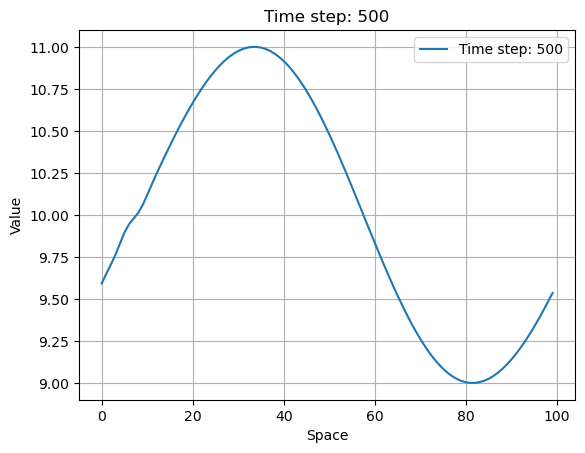

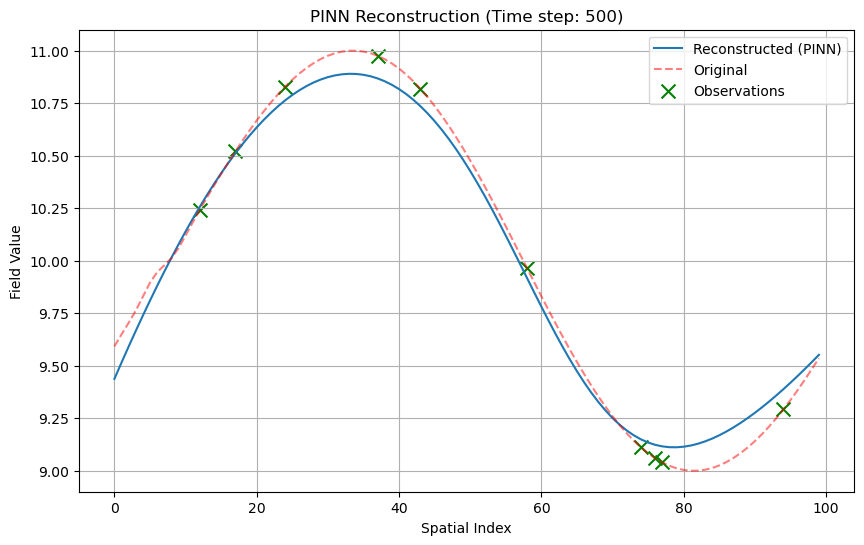

Epoch 0, Loss: 0.091708
Epoch 100, Loss: 0.085973
Epoch 200, Loss: 0.085973
Epoch 300, Loss: 0.085973
Epoch 400, Loss: 0.085973
Epoch 500, Loss: 0.085973
Epoch 600, Loss: 0.085973
Epoch 700, Loss: 0.085973
Epoch 800, Loss: 0.085973
Epoch 900, Loss: 0.085973


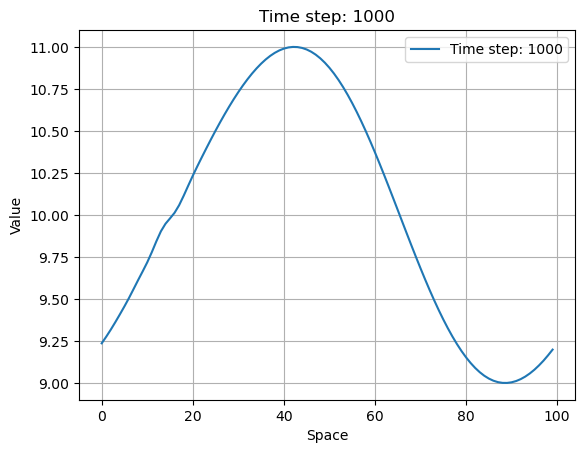

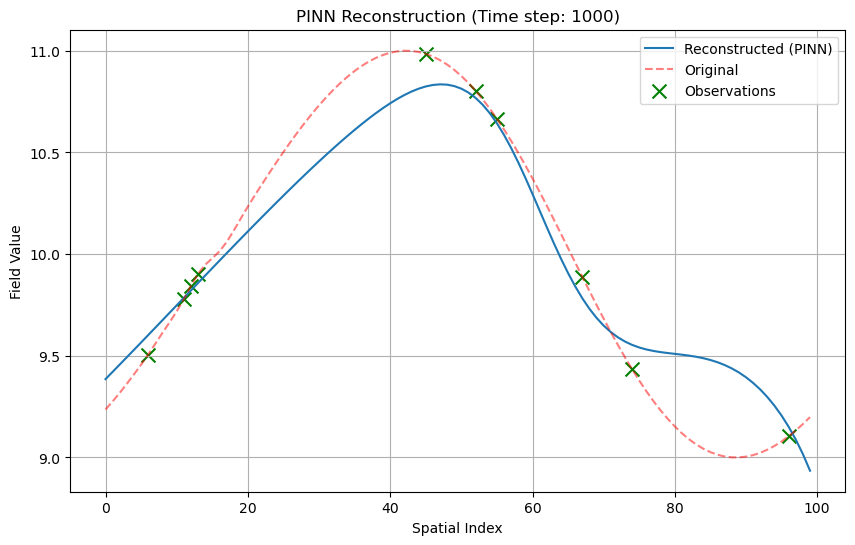

Epoch 0, Loss: 0.096807
Epoch 100, Loss: 0.086235
Epoch 200, Loss: 0.086235
Epoch 300, Loss: 0.086235
Epoch 400, Loss: 0.086235
Epoch 500, Loss: 0.086235
Epoch 600, Loss: 0.086235
Epoch 700, Loss: 0.086235
Epoch 800, Loss: 0.086235
Epoch 900, Loss: 0.086235


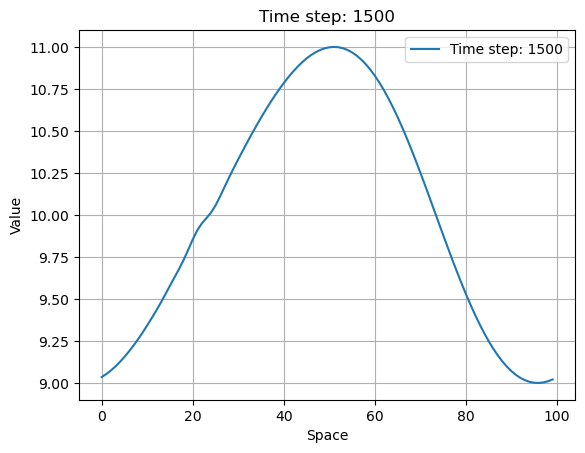

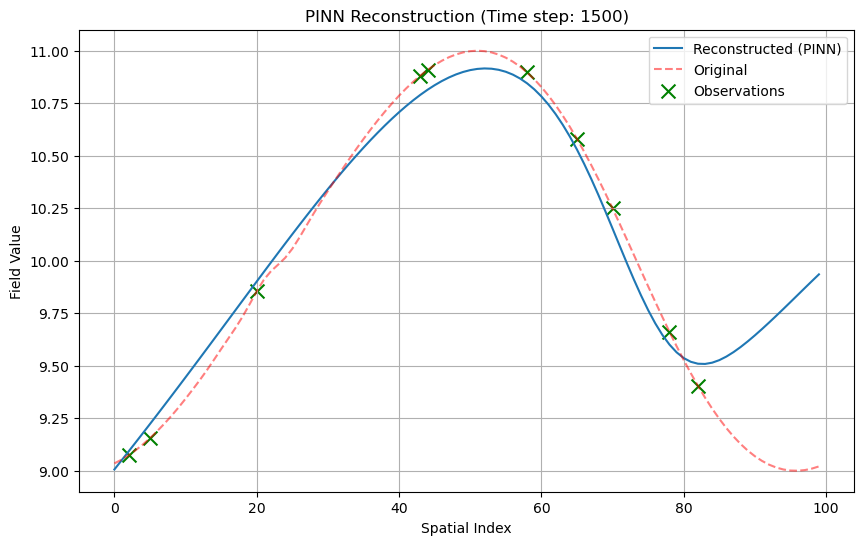

Epoch 0, Loss: 0.095358
Epoch 100, Loss: 0.095358
Epoch 200, Loss: 0.095358
Epoch 300, Loss: 0.095358
Epoch 400, Loss: 0.095358
Epoch 500, Loss: 0.095358
Epoch 600, Loss: 0.095358
Epoch 700, Loss: 0.095358
Epoch 800, Loss: 0.095358
Epoch 900, Loss: 0.095358


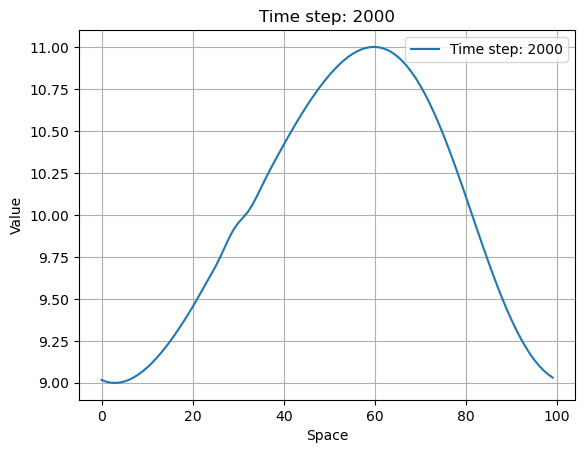

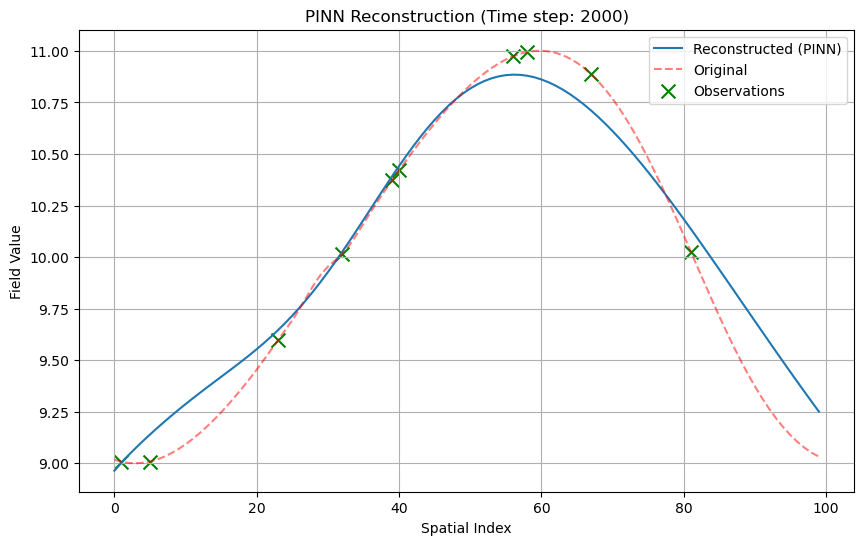

Epoch 0, Loss: 0.095913
Epoch 100, Loss: 0.094702
Epoch 200, Loss: 0.094702
Epoch 300, Loss: 0.094702
Epoch 400, Loss: 0.094702
Epoch 500, Loss: 0.094702
Epoch 600, Loss: 0.094702
Epoch 700, Loss: 0.094702
Epoch 800, Loss: 0.094702
Epoch 900, Loss: 0.094702


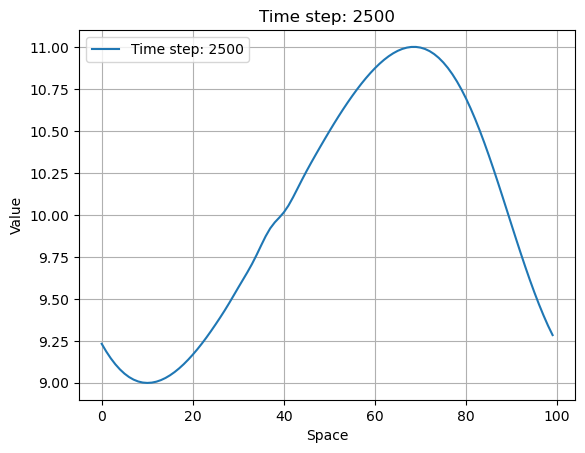

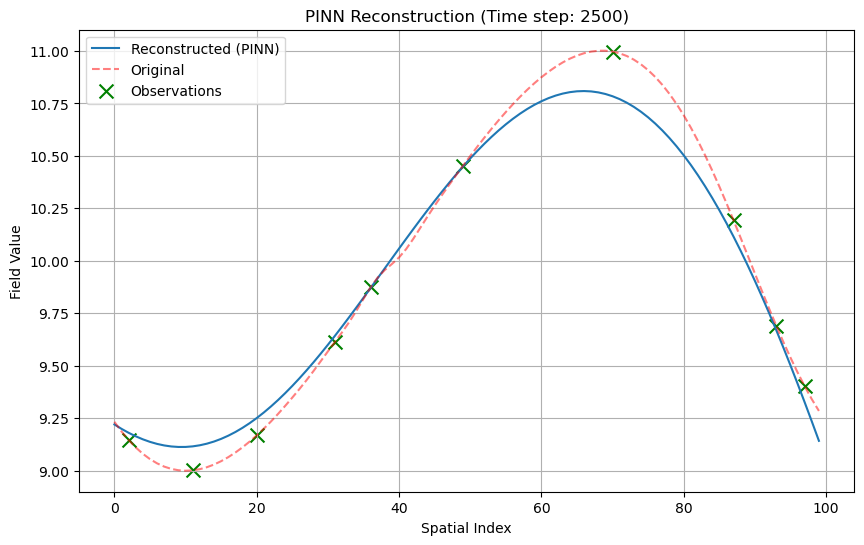

Epoch 0, Loss: 0.091802
Epoch 100, Loss: 0.083167
Epoch 200, Loss: 0.083167
Epoch 300, Loss: 0.083167
Epoch 400, Loss: 0.083167
Epoch 500, Loss: 0.083167
Epoch 600, Loss: 0.083167
Epoch 700, Loss: 0.083167
Epoch 800, Loss: 0.083167
Epoch 900, Loss: 0.083167


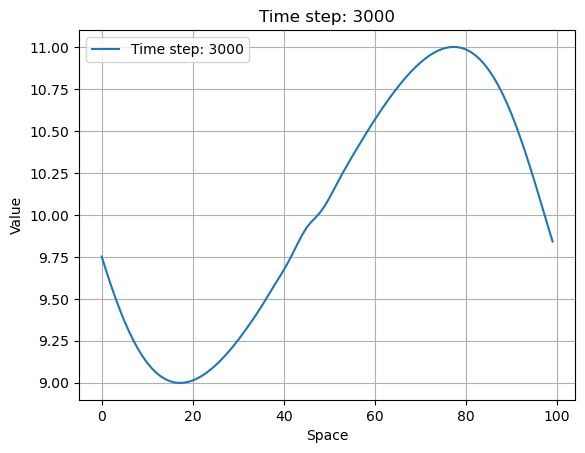

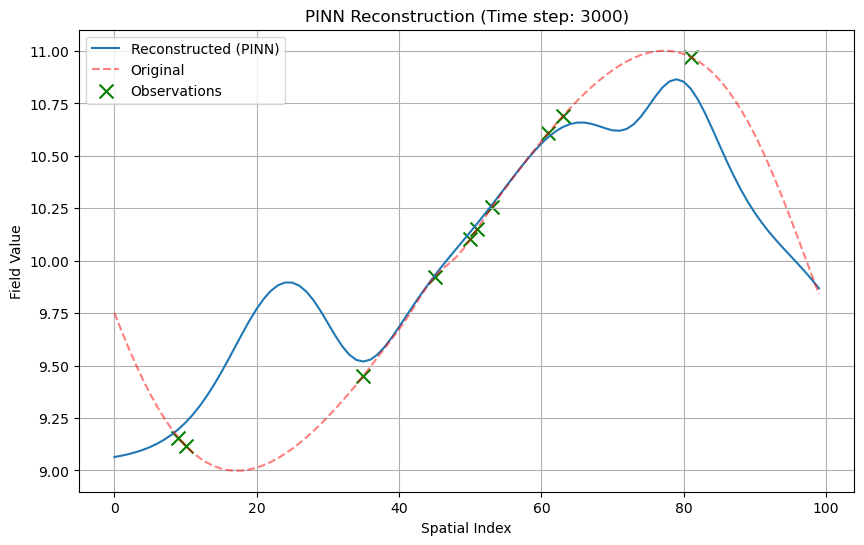

Epoch 0, Loss: 0.095945
Epoch 100, Loss: 0.085165
Epoch 200, Loss: 0.085165
Epoch 300, Loss: 0.085165
Epoch 400, Loss: 0.085165
Epoch 500, Loss: 0.085165
Epoch 600, Loss: 0.085165
Epoch 700, Loss: 0.085165
Epoch 800, Loss: 0.085165
Epoch 900, Loss: 0.085165


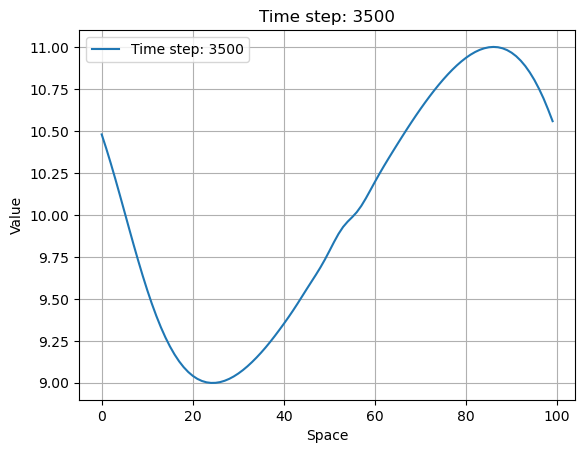

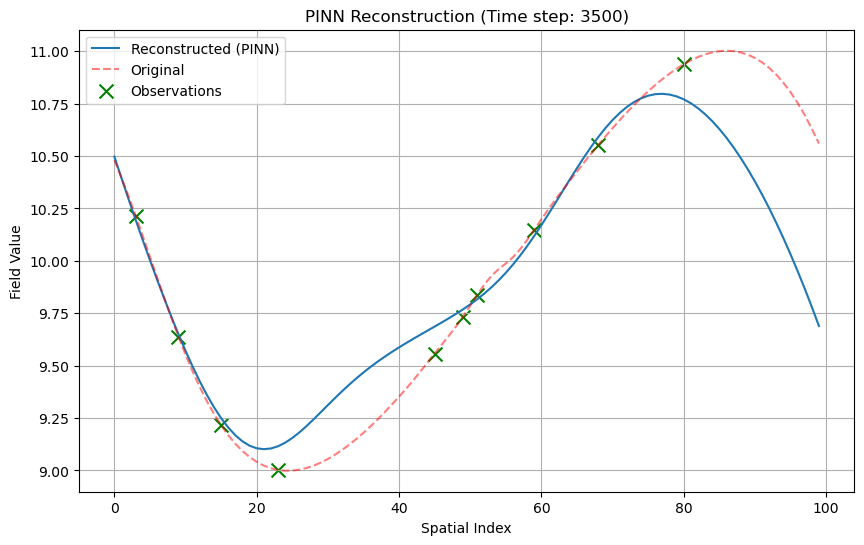

Epoch 0, Loss: 0.352613
Epoch 100, Loss: 0.352613
Epoch 200, Loss: 0.352613
Epoch 300, Loss: 0.352613
Epoch 400, Loss: 0.352613
Epoch 500, Loss: 0.352613
Epoch 600, Loss: 0.352613
Epoch 700, Loss: 0.352613
Epoch 800, Loss: 0.352613
Epoch 900, Loss: 0.352613


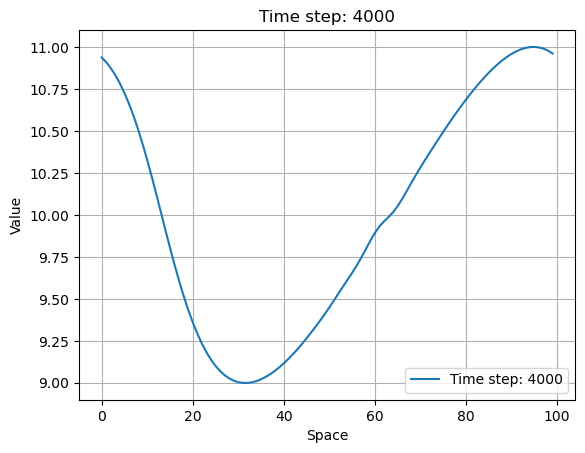

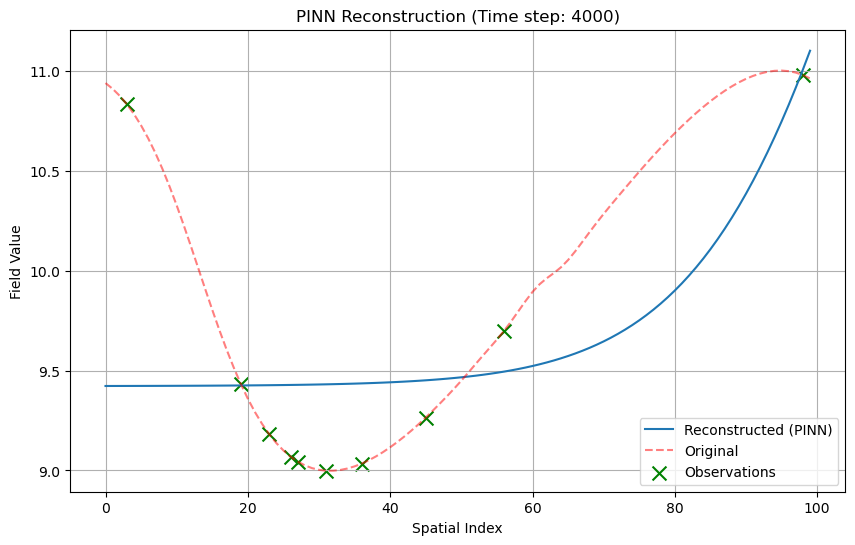

Epoch 0, Loss: 0.086198
Epoch 100, Loss: 0.085907
Epoch 200, Loss: 0.085907
Epoch 300, Loss: 0.085907
Epoch 400, Loss: 0.085907
Epoch 500, Loss: 0.085907
Epoch 600, Loss: 0.085907
Epoch 700, Loss: 0.085907
Epoch 800, Loss: 0.085907
Epoch 900, Loss: 0.085907


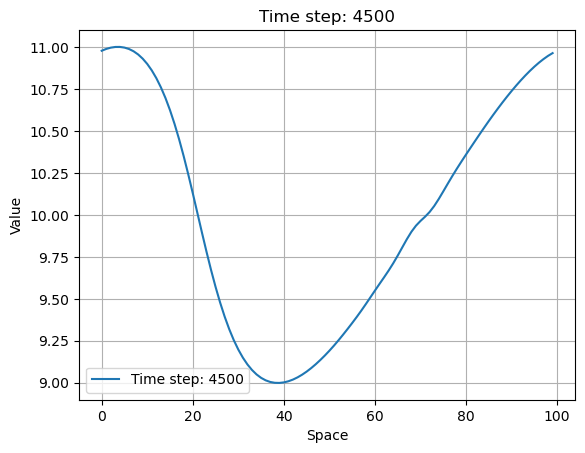

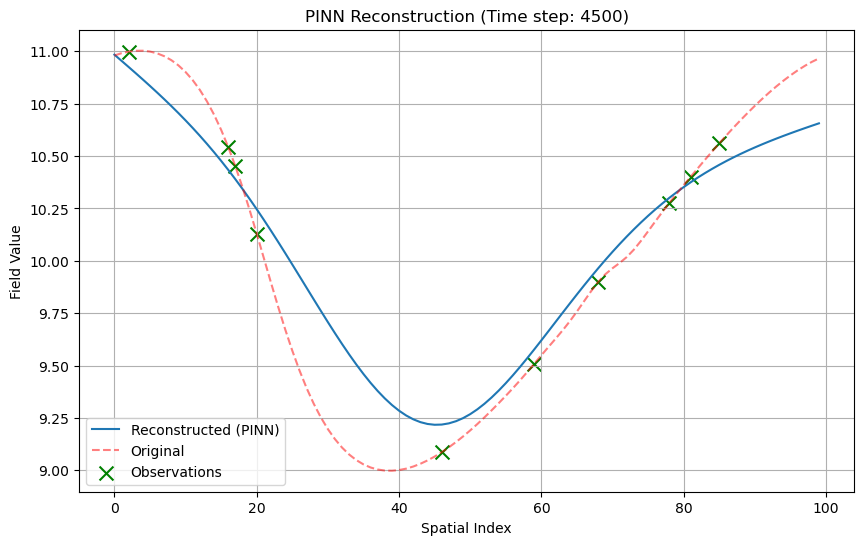

Epoch 0, Loss: 0.073019
Epoch 100, Loss: 0.073019
Epoch 200, Loss: 0.073019
Epoch 300, Loss: 0.073019
Epoch 400, Loss: 0.073019
Epoch 500, Loss: 0.073019
Epoch 600, Loss: 0.073019
Epoch 700, Loss: 0.073019
Epoch 800, Loss: 0.073019
Epoch 900, Loss: 0.073019


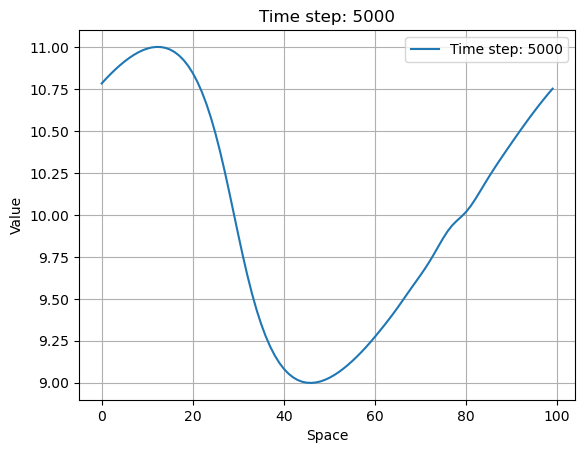

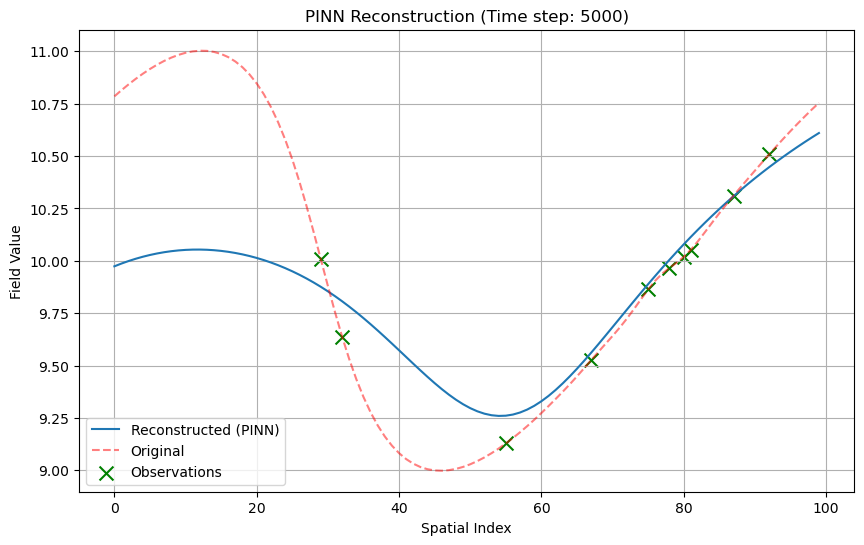

In [ ]:
exp3 = FiniteDifference(Tsc.RungeKutta, Ssc.WENO, Nt, Nx, endtime, endspace, 0.00)
%timeit exp3.run()